In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import json

In [3]:
df = pd.read_csv("../processed/tx_cvap_rejected_ballots_data.csv", dtype={"region_id": str})
df

,region_id,cvap_white,cvap_black,cvap_hispanic,cvap_asian,cvap_other,cvap_total,total_ballots_cast,mail_reject_total
0,4800100000,26950,8695,6770,245,1820,44480,19548,119
1,4800300000,5465,345,5450,20,165,11445,6082,1
2,4800500000,40595,7610,8720,690,2550,60165,34624,62
3,4800700000,14395,255,4440,230,665,19985,13173,90
4,4800900000,5935,25,365,20,155,6500,5149,1
...,...,...,...,...,...,...,...,...,...
249,4849900000,31235,1480,2615,130,745,36205,24618,101
250,4850100000,1570,10,2315,30,165,4090,2406,9
251,4850300000,10830,170,1680,0,285,12965,8394,0
252,4850500000,540,35,6545,30,35,7185,5038,1


In [4]:
df = df[
    (df["total_ballots_cast"] > 0) &
    (df["mail_reject_total"] >= 0)
].copy()

df["rejection_probability"] = (
    df["mail_reject_total"] / df["total_ballots_cast"]
)
df["rejection_probability"].describe()

count    254.000000
mean       0.005444
std        0.009890
min        0.000000
25%        0.000934
50%        0.003063
75%        0.006794
max        0.136364
Name: rejection_probability, dtype: float64

In [5]:
def weighted_kde(x, weights, grid):
    kde = gaussian_kde(x, weights=weights)
    y = kde(grid)
    return y / y.sum()

In [6]:
x = df["rejection_probability"].values

rejection_grid = np.linspace(
    x.min(),
    x.max(),
    200
)

In [7]:
groups = {
    "white": "cvap_white",
    "black": "cvap_black",
    "hispanic": "cvap_hispanic",
    "asian": "cvap_asian",
    "other": "cvap_other"
}

curves = {}

for group, col in groups.items():
    work = pd.DataFrame({
        "rejection_prob": df["rejection_probability"],
        "group_cvap": df[col],
        "cvap_total": df["cvap_total"]
    })

    work = work[
        (work["cvap_total"] > 0) &
        (work["group_cvap"] >= 0) &
        (work["rejection_prob"].notna())
    ]

    if work.empty:
        continue

    weights = work["group_cvap"] / work["cvap_total"]
    weights = weights.clip(lower=0)

    curves[group] = weighted_kde(
        work["rejection_prob"].values,
        weights.values,
        rejection_grid
    )

work.describe()

,rejection_prob,group_cvap,cvap_total
count,252.000000,252.000000,2.520000e+02
mean,0.005469,1774.333333,7.725899e+04
std,0.009924,6094.903901,2.583626e+05
min,0.000000,0.000000,5.500000e+01
25%,0.000955,80.000000,4.323750e+03
50%,0.003063,250.000000,1.316750e+04
75%,0.006854,892.500000,3.843000e+04
max,0.136364,61295.000000,2.845385e+06


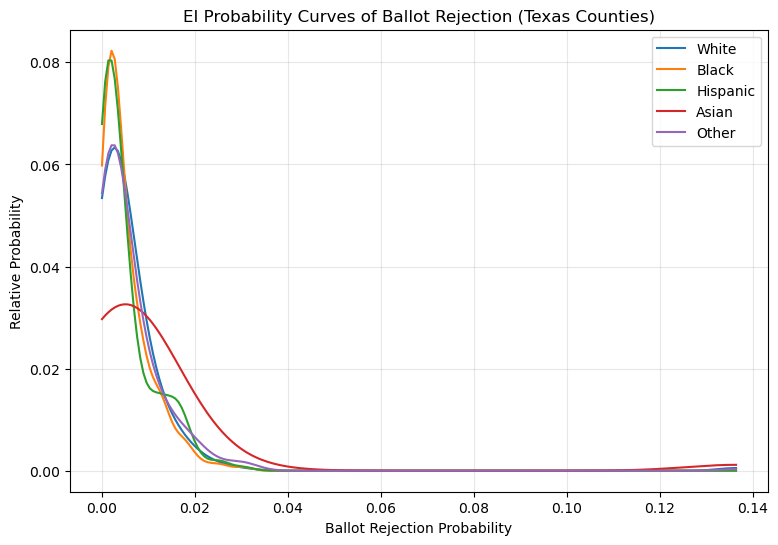

In [8]:
plt.figure(figsize=(9, 6))

for group, y in curves.items():
    plt.plot(
        rejection_grid,
        y,
        label=group.capitalize()
    )

plt.xlabel("Ballot Rejection Probability")
plt.ylabel("Relative Probability")
plt.title("EI Probability Curves of Ballot Rejection (Texas Counties)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [10]:
ei_points = {}

for group, yvals in curves.items():
    ei_points[group] = [
        {"x": float(x), "y": float(y)}
        for x, y in zip(rejection_grid, yvals)
    ]

with open("../processed/tx_ei_rejected_ballot_curves.json", "w") as f:
    json.dump(ei_points, f, indent=2)

print("Created JSON with X and Y points only")

Created JSON with X and Y points only
